# 02. Exploratory Data Analysis

This notebook performs comprehensive exploratory data analysis on the Electric Vehicle Population Data to understand patterns and identify optimal locations for charging stations.

## Objectives:
1. Analyze EV distribution by geographic regions
2. Identify high-density EV areas
3. Explore vehicle characteristics and trends
4. Visualize spatial patterns
5. Generate insights for charging station placement


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_ev_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Model Year'].min()} - {df['Model Year'].max()}")
print(f"States: {df['State'].unique()}")
print(f"Counties: {df['County'].nunique()}")

df.head()


Dataset shape: (250659, 20)
Date range: 2000 - 2026
States: ['Wa' 'Bc' 'Ns' 'Ky' 'Ca' 'Nc' 'Dc' 'Mi' 'Ks' 'Or' 'Al' 'Md' 'Il' 'Az'
 'Ny' 'Ga' 'Va' 'Wy' 'Ne' 'Co' 'Ut' 'Nv' 'Mo' 'Tx' 'Nj' 'Ok' 'Fl' 'Ri'
 'Tn' 'Ct' 'Nh' 'Ma' 'Hi' 'Wi' 'Oh' 'Me' 'Pa' 'Ak' 'Id' 'De' 'In' 'Nm'
 'Mn' 'Ap' 'Ms' 'Sc' 'La' 'Gu']
Counties: 225


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Vehicle Age,Longitude,Latitude
0,5YJSA1E65N,Yakima,Granger,Wa,98932.0,2022,Tesla,Model S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,215.0,69900.0,15.0,187279214,POINT (-120.1871 46.33949),PACIFICORP,5.307700e+10,2,-120.18710,46.33949
1,KNDC3DLC5N,Yakima,Yakima,Wa,98902.0,2022,Kia,Ev6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,215.0,NaN,15.0,210098241,POINT (-120.52041 46.59751),PACIFICORP,5.307700e+10,2,-120.52041,46.59751
2,5YJYGDEEXL,Snohomish,Everett,Wa,98208.0,2020,Tesla,Model Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,NaN,44.0,121781950,POINT (-122.18637 47.89251),PUGET SOUND ENERGY INC,5.306104e+10,4,-122.18637,47.89251
3,3C3CFFGE1G,Yakima,Yakima,Wa,98908.0,2016,Fiat,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,NaN,14.0,180778377,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10,8,-120.60199,46.59817
4,KNDCC3LD5K,Kitsap,Bremerton,Wa,98312.0,2019,Kia,Niro,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,NaN,26.0,2581225,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10,5,-122.65223,47.57192


EV Distribution Analysis
Top 15 Counties by EV Count:
           EV_Count  Avg_Range  Avg_MSRP  Avg_Model_Year
County                                                  
King         124211     179.15  60565.30         2021.76
Snohomish     31031     182.90  60283.93         2021.81
Pierce        20829     172.54  59421.76         2021.64
Clark         15279     165.79  60546.52         2021.57
Thurston       9175     167.42  56912.34         2021.32
Kitsap         8479     165.24  59203.00         2021.37
Spokane        7123     158.64  57961.79         2021.63
Whatcom        6144     161.32  57577.14         2020.96
Benton         3391     165.23  61267.82         2021.34
Skagit         2941     169.92  59798.60         2021.31
Island         2751     166.01  60206.39         2021.17
Yakima         1693     164.07  63129.30         2021.29
Chelan         1553     177.95  66761.50         2021.57
Clallam        1527     154.26  55627.18         2020.90
Jefferson      1320     158.40  58

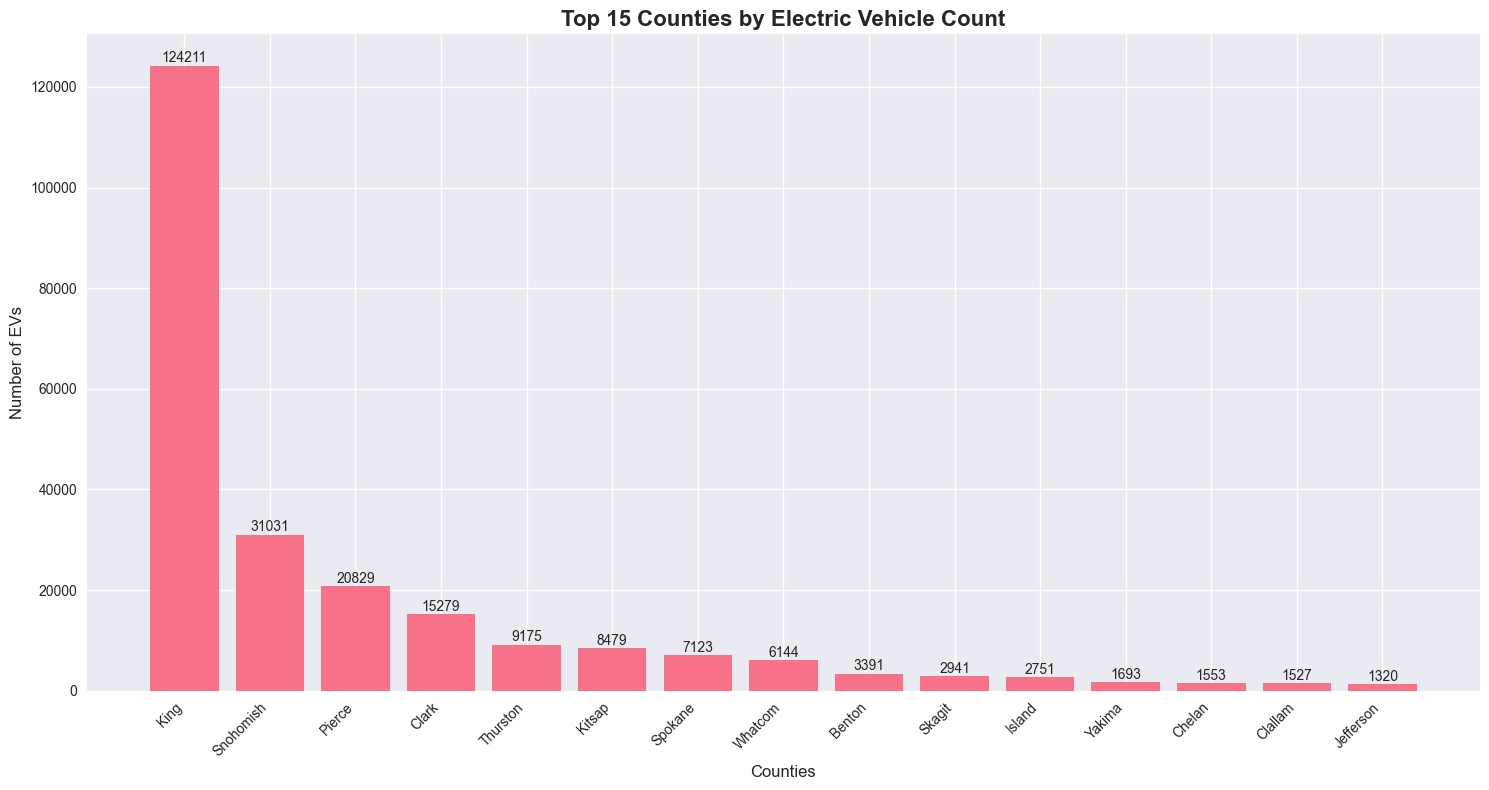

In [3]:
# 1. EV Distribution by County
print("EV Distribution Analysis")
print("=" * 50)

# Top counties by EV count
county_stats = df.groupby('County').agg({
    'VIN (1-10)': 'count',
    'Electric Range': 'mean',
    'Base MSRP': 'mean',
    'Model Year': 'mean'
}).round(2)

county_stats.columns = ['EV_Count', 'Avg_Range', 'Avg_MSRP', 'Avg_Model_Year']
county_stats = county_stats.sort_values('EV_Count', ascending=False)

print("Top 15 Counties by EV Count:")
print(county_stats.head(15))

# Visualize top counties
plt.figure(figsize=(15, 8))
top_counties = county_stats.head(15)
bars = plt.bar(range(len(top_counties)), top_counties['EV_Count'])
plt.title('Top 15 Counties by Electric Vehicle Count', fontsize=16, fontweight='bold')
plt.xlabel('Counties', fontsize=12)
plt.ylabel('Number of EVs', fontsize=12)
plt.xticks(range(len(top_counties)), top_counties.index, rotation=45, ha='right')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [4]:
# 2. City-level Analysis for Charging Station Placement
print("\nCity-level Analysis")
print("=" * 30)

# Top cities by EV count
city_stats = df.groupby(['County', 'City']).agg({
    'VIN (1-10)': 'count',
    'Electric Range': 'mean',
    'Base MSRP': 'mean',
    'Longitude': 'mean',
    'Latitude': 'mean'
}).round(4)

city_stats.columns = ['EV_Count', 'Avg_Range', 'Avg_MSRP', 'Longitude', 'Latitude']
city_stats = city_stats.sort_values('EV_Count', ascending=False)

print("Top 20 Cities by EV Count:")
print(city_stats.head(20))

# Create charging station suitability score
# Factors: EV count, average range, average MSRP (affordability)
city_stats['Charging_Score'] = (
    city_stats['EV_Count'] * 0.5 +  # Primary factor: number of EVs
    (city_stats['Avg_Range'] / 100) * 0.3 +  # Secondary: range (normalized)
    (100000 / city_stats['Avg_MSRP']) * 0.2  # Tertiary: affordability (inverse of MSRP)
).round(2)

city_stats = city_stats.sort_values('Charging_Score', ascending=False)
print("\nTop 20 Cities by Charging Station Suitability Score:")
print(city_stats[['EV_Count', 'Avg_Range', 'Avg_MSRP', 'Charging_Score']].head(20))



City-level Analysis
Top 20 Cities by EV Count:
                         EV_Count  Avg_Range    Avg_MSRP  Longitude  Latitude
County    City                                                               
King      Seattle           39768   172.6144  59311.1934  -122.3380   47.6309
          Bellevue          12202   188.7518  64703.2123  -122.1415   47.6009
Clark     Vancouver          9322   162.5425  59576.3375  -122.5950   45.6621
King      Redmond            8653   189.6672  62741.2952  -122.1067   47.6817
          Kirkland           7163   185.0123  64439.0444  -122.2163   47.6979
          Sammamish          7021   191.8534  64422.1760  -122.0244   47.6008
          Renton             6893   168.7618  49153.4395  -122.1562   47.4710
Snohomish Bothell            6516   191.3077  61353.3811  -122.1993   47.8211
Thurston  Olympia            5956   167.4788  57152.1329  -122.8753   47.0370
Pierce    Tacoma             5569   167.7285  58605.6188  -122.4542   47.2392
King      Kent  

In [5]:
# 3. Interactive Map Visualization
print("Creating Interactive Map...")

# Create a map centered on Washington state
m = folium.Map(
    location=[47.7511, -120.7401],  # Washington state center
    zoom_start=7,
    tiles='OpenStreetMap'
)

# Add markers for top cities
top_cities = city_stats.head(50).reset_index()

for idx, row in top_cities.iterrows():
    if pd.notna(row['Latitude']) and pd.notna(row['Longitude']):
        # Color based on charging score
        if row['Charging_Score'] > 100:
            color = 'red'
        elif row['Charging_Score'] > 50:
            color = 'orange'
        else:
            color = 'green'
        
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=min(row['EV_Count']/50, 20),  # Size based on EV count
            popup=f"""
            <b>{row['City']}, {row['County']}</b><br>
            EVs: {int(row['EV_Count'])}<br>
            Avg Range: {row['Avg_Range']:.0f} miles<br>
            Avg MSRP: ${row['Avg_MSRP']:,.0f}<br>
            Charging Score: {row['Charging_Score']:.1f}
            """,
            color=color,
            fill=True,
            fillOpacity=0.7
        ).add_to(m)

# Add a legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 90px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
<p><b>Charging Station Suitability</b></p>
<p><i class="fa fa-circle" style="color:red"></i> High Priority (>100)</p>
<p><i class="fa fa-circle" style="color:orange"></i> Medium Priority (50-100)</p>
<p><i class="fa fa-circle" style="color:green"></i> Low Priority (<50)</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
m.save('../data/processed/ev_charging_map.html')
print("Interactive map saved to: ../data/processed/ev_charging_map.html")

# Display the map
m


Creating Interactive Map...
Interactive map saved to: ../data/processed/ev_charging_map.html


Vehicle Type and Model Analysis
Electric Vehicle Type Distribution:
Electric Vehicle Type
Battery Electric Vehicle (BEV)            199538
Plug-in Hybrid Electric Vehicle (PHEV)     51121
Name: count, dtype: int64

Top 20 EV Models:
Make        Model             
Tesla       Model Y               51903
            Model 3               37334
Nissan      Leaf                  13959
Tesla       Model S                7883
Chevrolet   Bolt Ev                7598
Tesla       Model X                6660
Ford        Mustang Mach-E         5472
Volkswagen  Id.4                   5252
Jeep        Wrangler               4706
Hyundai     Ioniq 5                4682
Chevrolet   Volt                   4664
Rivian      R1S                    4213
Toyota      Rav4 Prime (Phev)      4170
Kia         Niro                   4074
Toyota      Prius Prime (Phev)     3679
Chrysler    Pacifica               3587
Kia         Ev6                    3566
Ford        F-150                  3439
Bmw         X5  

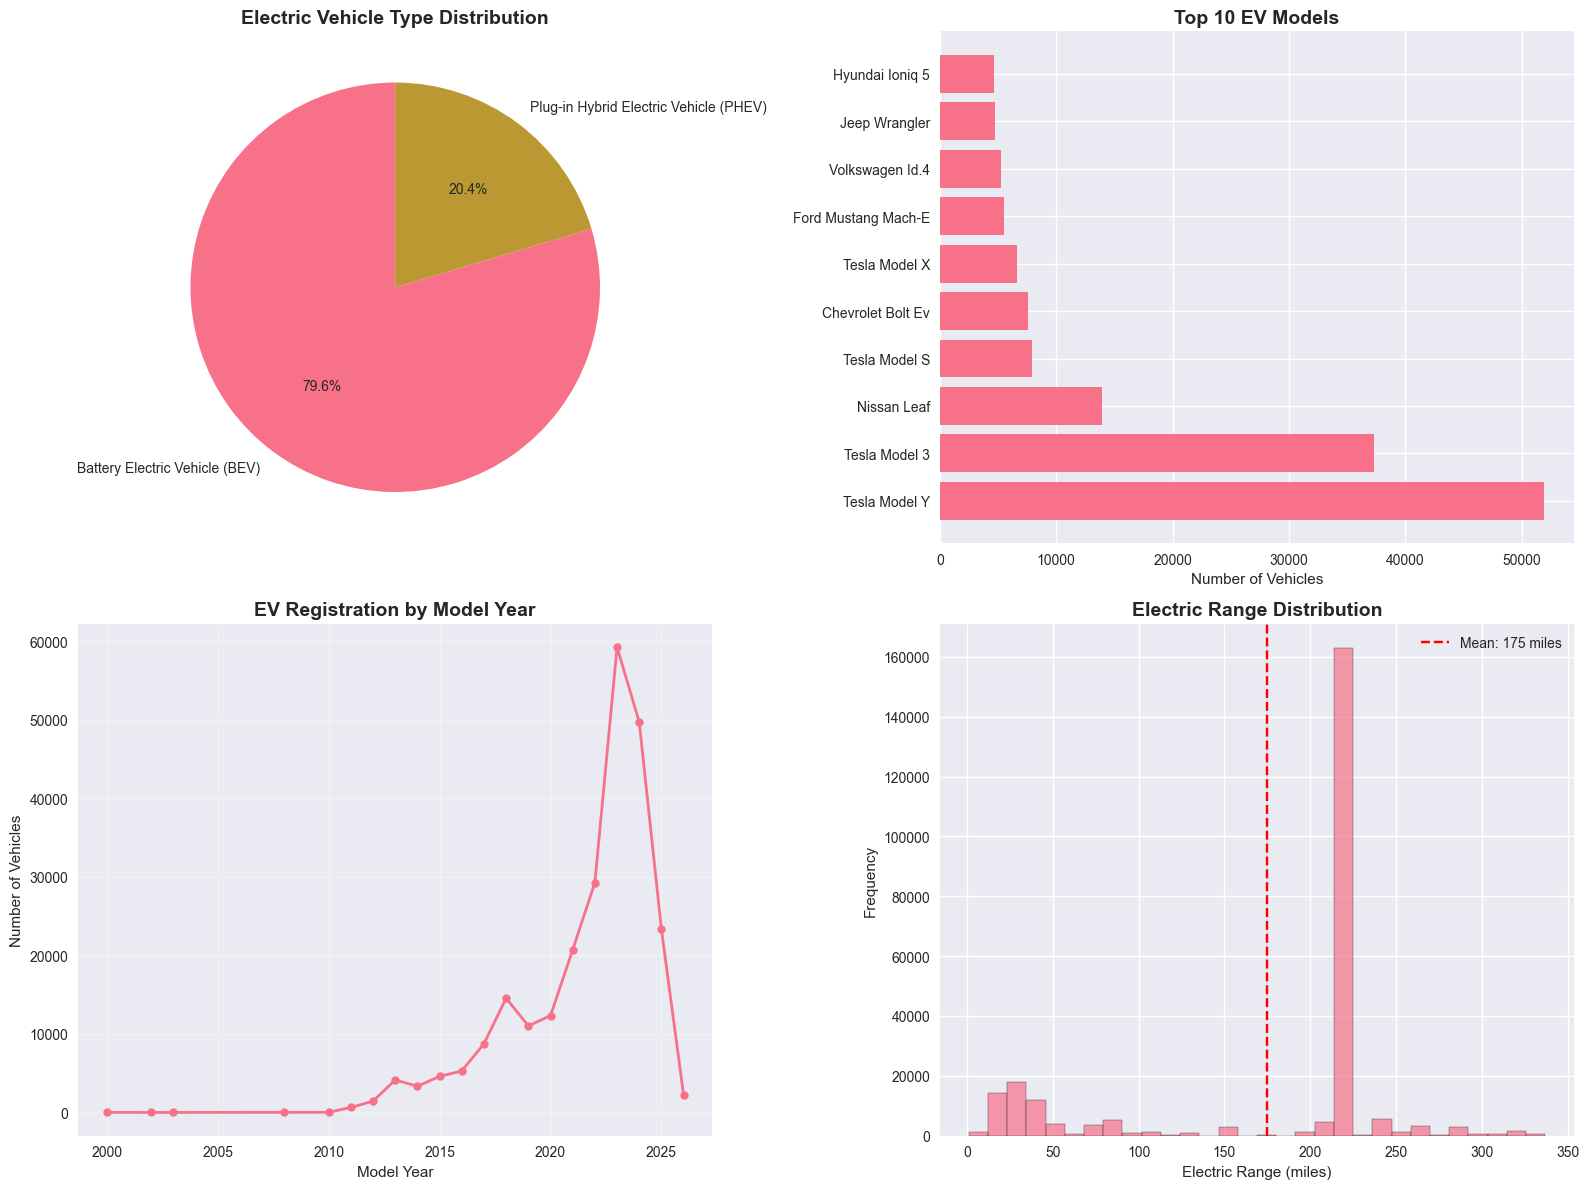

In [6]:
# 4. Vehicle Type and Model Analysis
print("Vehicle Type and Model Analysis")
print("=" * 40)

# EV Type distribution
ev_type_dist = df['Electric Vehicle Type'].value_counts()
print("Electric Vehicle Type Distribution:")
print(ev_type_dist)

# Top models
model_dist = df.groupby(['Make', 'Model']).size().sort_values(ascending=False).head(20)
print("\nTop 20 EV Models:")
print(model_dist)

# Visualize EV types and top models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# EV Type pie chart
axes[0,0].pie(ev_type_dist.values, labels=ev_type_dist.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Electric Vehicle Type Distribution', fontsize=14, fontweight='bold')

# Top 10 models bar chart
top_models = model_dist.head(10)
model_labels = [f"{make} {model}" for make, model in top_models.index]
axes[0,1].barh(range(len(top_models)), top_models.values)
axes[0,1].set_yticks(range(len(top_models)))
axes[0,1].set_yticklabels(model_labels, fontsize=10)
axes[0,1].set_title('Top 10 EV Models', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Number of Vehicles')

# Model year distribution
year_dist = df['Model Year'].value_counts().sort_index()
axes[1,0].plot(year_dist.index, year_dist.values, marker='o', linewidth=2, markersize=6)
axes[1,0].set_title('EV Registration by Model Year', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Model Year')
axes[1,0].set_ylabel('Number of Vehicles')
axes[1,0].grid(True, alpha=0.3)

# Electric range distribution
axes[1,1].hist(df['Electric Range'], bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Electric Range Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Electric Range (miles)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(df['Electric Range'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["Electric Range"].mean():.0f} miles')
axes[1,1].legend()

plt.tight_layout()
plt.show()


In [7]:
# 5. Save Analysis Results
print("Saving Analysis Results...")

# Save county statistics
county_stats.to_csv('../data/processed/county_ev_stats.csv')
print("✓ County statistics saved")

# Save city statistics with charging scores
city_stats.to_csv('../data/processed/city_charging_scores.csv')
print("✓ City charging scores saved")

# Create summary report
summary_report = {
    'total_evs': len(df),
    'total_counties': df['County'].nunique(),
    'total_cities': df['City'].nunique(),
    'avg_electric_range': df['Electric Range'].mean(),
    'avg_msrp': df['Base MSRP'].mean(),
    'top_county': county_stats.index[0],
    'top_city': city_stats.index[0][1],
    'bev_percentage': (df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)').mean() * 100,
    'phev_percentage': (df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)').mean() * 100
}

# Save summary
import json
with open('../data/processed/analysis_summary.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print("✓ Analysis summary saved")
print("\nAnalysis Summary:")
print("=" * 30)
for key, value in summary_report.items():
    if isinstance(value, float):
        print(f"{key.replace('_', ' ').title()}: {value:.2f}")
    else:
        print(f"{key.replace('_', ' ').title()}: {value}")

print("\nExploratory Data Analysis completed successfully!")


Saving Analysis Results...
✓ County statistics saved
✓ City charging scores saved
✓ Analysis summary saved

Analysis Summary:
Total Evs: 250659
Total Counties: 225
Total Cities: 821
Avg Electric Range: 174.58
Avg Msrp: 59983.33
Top County: King
Top City: Seattle
Bev Percentage: 79.61
Phev Percentage: 20.39

Exploratory Data Analysis completed successfully!
